In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [11]:
df.columns = ['CustomerID', 'Gender', 'Age', 'Income', 'SpendingScore']

In [12]:
df = df.drop('CustomerID', axis=1)

EDA

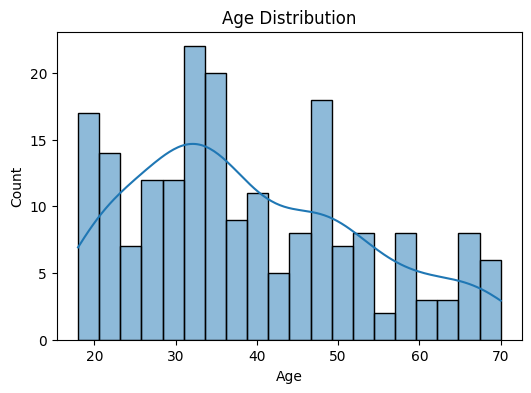

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

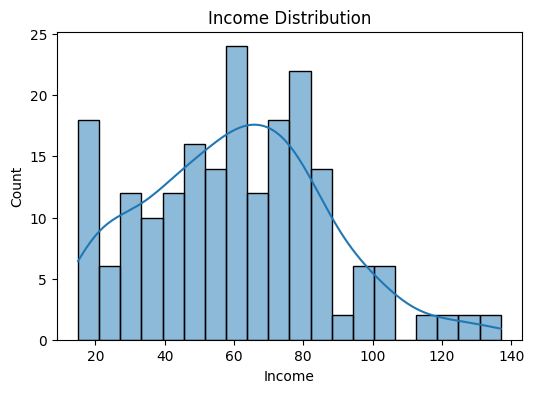

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['Income'], bins=20, kde=True)
plt.title("Income Distribution")
plt.show()

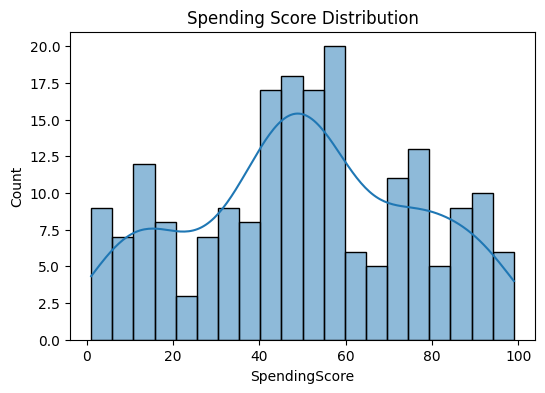

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['SpendingScore'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

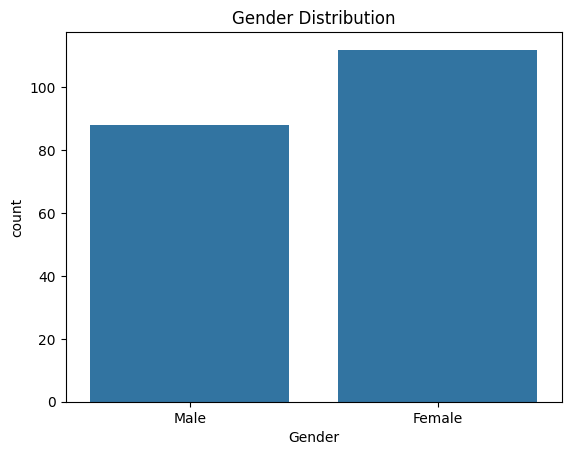

In [16]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

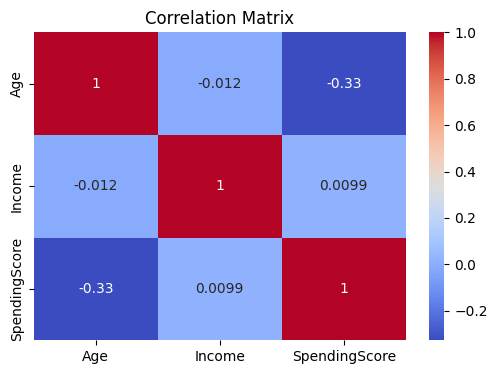

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age','Income','SpendingScore']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

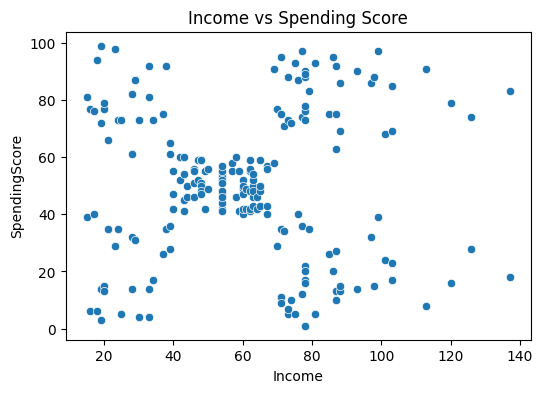

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Income', y='SpendingScore', data=df)
plt.title("Income vs Spending Score")
plt.show()

Feature Dataset

In [19]:
X = df[['Income', 'SpendingScore']]
X.head()

,Income,SpendingScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


K means clustering

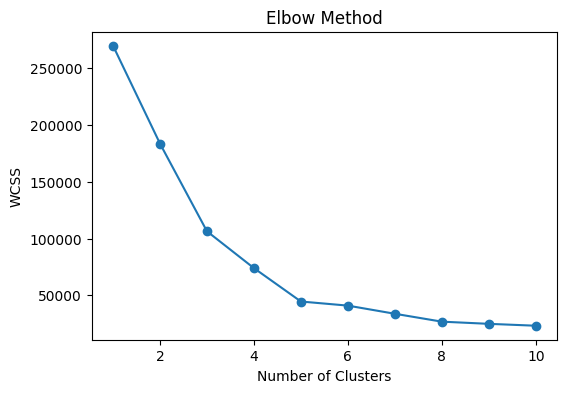

In [20]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [21]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

In [22]:
df['Cluster'] = y_kmeans

In [23]:
df.head()

,Gender,Age,Income,SpendingScore,Cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


Visualize Clusters

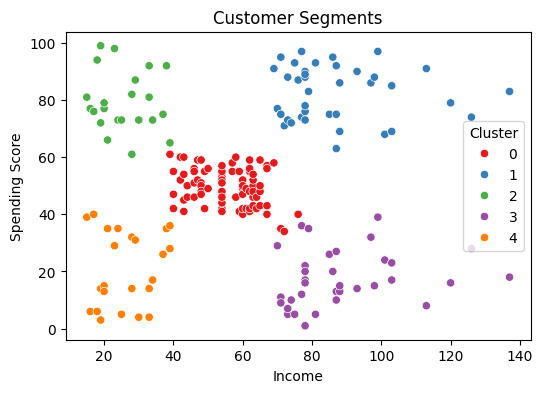

In [24]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df['Income'],
    y=df['SpendingScore'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segments")
plt.xlabel("Income")
plt.ylabel("Spending Score")

plt.show()

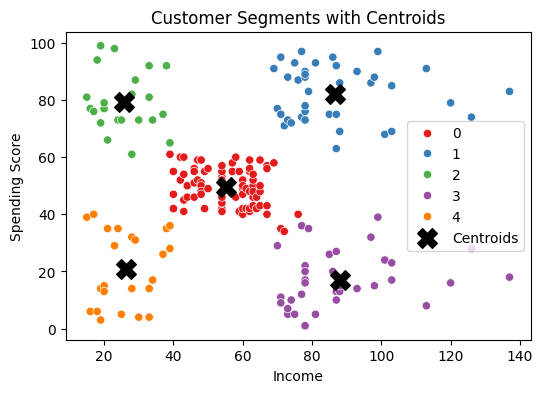

In [25]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df['Income'],
    y=df['SpendingScore'],
    hue=df['Cluster'],
    palette='Set1'
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segments with Centroids")
plt.xlabel("Income")
plt.ylabel("Spending Score")

plt.legend()
plt.show()

In [26]:
df.groupby('Cluster')[['Age', 'Income', 'SpendingScore']].mean()

,Age,Income,SpendingScore
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043
